# Cuaderno 6: Convoluciones

En este cuaderno mostraremos algunos conceptos básicos sobre la convolución y los campos receptivos.

Para comprender la visión humana, es esencial entender las primeras etapas del procesamiento de imágenes en la vía visual. Un problema común al encontrar bordes es que las imágenes no son perfectas; contienen imperfecciones conocidas como ruido. La teoría aborda el problema del ruido desenfocando las imágenes, mediante un proceso llamado convolución. Básicamente, consiste en aplicar un tipo particular de operador a lo largo de la imagen. Este operador tiene un perfil gaussiano porque la teoría computacional especifica que esta es la forma que optimiza la combinación de suavizar el ruido sin afectar demasiado las zonas donde se encuentran los bordes en la imagen convolucionada. El siguiente paso es identificar las regiones de la imagen donde hay cambios abruptos en las intensidades, ya que ahí es donde están los bordes. Esto requiere medir gradientes de intensidad y/o cambios en los gradientes, que se conocen como la primera y segunda derivadas, respectivamente. Se describen varios algoritmos biológicamente plausibles para implementar la teoría. Estos algoritmos implican operadores notablemente similares a los campos receptivos de las células en la retina y la corteza estriada.

Las representaciones cerebrales de los bordes no pueden ser lo único implicado en la visión, ya que somos capaces de describir características de la escena mucho más complejas que los bordes. Aun así, las representaciones de los bordes pueden ser útiles de inmediato para guiar una acción de agarre en torno a un objeto. Además, pueden servir como un primer paso importante en tareas perceptuales más complejas, como el reconocimiento de objetos o la percepción de profundidad.

- Capítulos 3, 5 y 9 de Frisby, J. P. & Stone, J. V. *Seeing*. (The MIT Press, London, 2010).
- Capítulo 7 de Trappenberg, T. P. *Fundamentals of Computational Neuroscience*. (Oxford University Press, Oxford, 2022).

Comenzamos importando las librerías que vamos a usar y descargando algunas imágenes de prueba:

In [2]:
import numpy as np
import scipy as sp
#import cv2
import matplotlib.pyplot as plt
import matplotlib.image as img


# Descargamos el archivo con las imagenes
#!wget -c  https://www.dropbox.com/s/s6avvlzotznxfn3/imagenes_convolucion_ncc.zip
#!unzip -d ./ imagenes_convolucion_ncc.zip

La imagen tiene un tamaño de (427, 640)


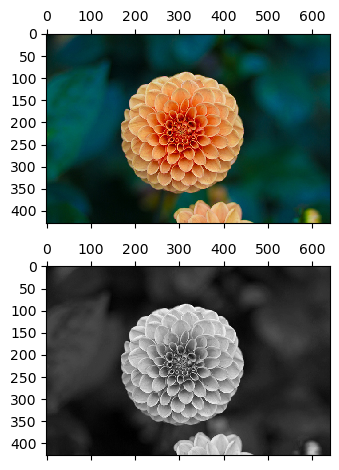

In [15]:
from sklearn.datasets import load_sample_images
dataset = load_sample_images()     

imagen_original = dataset.images[1]
imagen_gris = np.mean(imagen_original, axis=2)
print(f"La imagen tiene un tamaño de {imagen_gris.shape}")

fig, (ax1, ax2) = plt.subplots(2, 1, layout="tight")
ax1.matshow(imagen_original)
ax2.matshow(imagen_gris, cmap="gray")
plt.show()

In [32]:
import matplotlib.patches as patches
import ipywidgets as widgets

@widgets.interact(x0=(0,imagen_gris.shape[1]-10), y0=(0,imagen_gris.shape[0]-10))
def roi(x0, y0):
  # Definimos una región de interés
  x1, y1 = x0 + 10, y0 + 10
  roi = imagen_gris[y0:y1, x0:x1]

  # Graficamos ambas matrices con un rectángulo sobre la imagen original
  fig, (ax1, ax2) = plt.subplots(1, 2, layout="tight")
  
  ax1.imshow(imagen_gris, cmap='gray', vmin=0, vmax=255)
  rect = patches.Rectangle((x0, y0), x1-x0, y1-y0,  linewidth=2, edgecolor='blue', facecolor='none')
  ax1.add_patch(rect)
  
  ax2.imshow(roi, cmap='gray', vmin=0, vmax=255)
  plt.show()
  
  print(f"La región de interés tiene un tamaño de {roi.shape}, y los siguientes valores numéricos:")
  print(roi.astype(int))
  print("Esa matriz numérica da lugar al siguiente pedazo de imagen:")
  
  

interactive(children=(IntSlider(value=315, description='x0', max=630), IntSlider(value=208, description='y0', …

En este cuaderno usaremos una imagen con manzanas. Las imagenes a color se componen de tres canales: rojo, verde y azul. Sin embargo, nosotros usaremos solo un canal, que se corresponde con su homólogo en blanco y negro:

In [3]:
# Cargamos el archivo con una imagen de manzanas
manzanas = img.imread("apple-fruit.jpg")
manzanas_imgray = np.mean(manzanas, axis=2)
print(f"La imagen tiene un tamaño de {manzanas_imgray.shape}")

fig, (ax1, ax2) = plt.subplots(2, 1, layout="tight")
ax1.matshow(manzanas)
ax2.matshow(manzanas_imgray, cmap="gray")

FileNotFoundError: [Errno 2] No such file or directory: 'apple-fruit.jpg'

Observa la escena que tienes delante y no tendrás problemas para identificar los bordes formados por los límites de las manzanas, las superficies, las marcas en las superficies y las sombras. Esta habilidad para ver los bordes debe reflejar el hecho de que existen representaciones de características de bordes en alguna parte de nuestro cerebro.

La imagen consiste en una matriz de números donde cada entrada indica la intensidad de un pixel en la imagen. Abajo imprimimos la representación numérica del pedazo de imagen arbitrario, y luego visualizamos la imagen que le corresponde.

In [ ]:
# Definimos una región de interés
x0, x1, y0, y1 = 200, 230,  10, 40 #580, 590, 300, 310
roi = manzanas_imgray[y0:y1, x0:x1]

# Dibujamos un rectángulo en la imagen original señalando la región de interés
panorama = np.copy(manzanas_imgray)
panorama = cv2.rectangle(panorama, (x0, y0), (x1, y1), (255,0,0), 3)

print(f"La región de interés tiene un tamaño de {roi.shape}, y los siguientes valores numéricos:")
print(roi.astype(int))
print("Esa matriz numérica da lugar al siguiente pedazo de imagen:")

# Graficamos ambas matrices
fig, (ax1, ax2) = plt.subplots(1, 2, layout="tight")
ax1.matshow(panorama, cmap='gray', vmin=0, vmax=255)
ax2.matshow(roi, cmap='gray', vmin=0, vmax=255)

> **Ejercicio**
>
> Pruebe con diferentes regiones de interés. Manteniendo un tamaño de $10 \times 10$, encuentre una donde aparezca el cabito de una manzana. ¿Tiene un borde nítido?

Para tener una mejor intuición de los cambios de luminancia en la imagen, graficamos abajo los valores de luminancia a lo largo de una fila. También graficamos el cambio en los valores de luminancia, es decir, la diferencia entre pixeles consecutivos.

In [ ]:
# Definimos una región de interés
No_fila=260
x1 = manzanas_imgray.shape[1]
roi = manzanas_imgray[No_fila, :]

# Dibujamos un rectángulo en la imagen original señalando la región de interés
panorama = np.copy(manzanas_imgray)
panorama = cv2.rectangle(panorama, (0, No_fila), (x1, No_fila), (255,0,0), 3)

# Calculamos la diferencia
diferencia = np.diff(roi)

# A continuación graficamos la intensidad de los píxeles en la fila
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, layout='constrained', height_ratios=[4, 1, 1, 1], figsize=(10, 7))

ax1.matshow(panorama, cmap='gray', vmin=0, vmax=255, aspect='auto')

ax2.matshow(roi.reshape(1, roi.shape[0]), cmap="gray", vmin=0, vmax=255, aspect='auto')
ax2.set(xlabel='Indice', ylabel='Intensidad', title=f'Corte a lo largo de la fila {No_fila}')

ax3.plot(roi)
ax3.set(xlabel='Indice', ylabel='Intensidad', title=f'Corte a lo largo de la fila {No_fila}')
ax3.set_xlim(0, x1)

ax4.plot(diferencia)
ax4.set(xlabel='Indice', ylabel='Intensidad', title='Diferencia entre pixeles consecutivos')
ax4.set_xlim(0, x1)

> **Ejercicio**
>
> Pruebe con diferentes filas y encuentre un corte en donde aparezcan las dos manzanas del frente.
>
> ¿Es fácil discernir los bordes de las manzanas a partir de las graficas que muestran la diferencia de luminosidad?

## Convoluciones en una dimensión

Ahora revisaremos una operación matemática importante llamada **convolución**. Una convolución es una operación matemática que combina dos funciones para producir una tercera. En el contexto de procesamiento de imágenes y redes neuronales, la convolución es usada para extraer características importantes, como bordes, texturas y patrones.

Imagina que tienes una imagen (que puedes ver como una matriz de píxeles) y un filtro o "kernel" (otra matriz más pequeña). La convolución consiste en deslizar este filtro sobre la imagen, multiplicando los valores de los píxeles por los valores del filtro y sumando los resultados en cada posición. Este proceso se repite a lo largo de toda la imagen, y el resultado es una nueva imagen donde se han resaltado ciertos rasgos de la imagen original, dependiendo del filtro usado.

Comenzaremos viendo que la convolución en una dimension. Luego la generalizaremos a dos dimensiones. Por ahora, el objetivo es detectar los bordes en una fila usando una convolución en lugar de la diferencia de píxeles consecutivos.

Supongamos que tenemos una señal $s$ dada por

$$t= \begin{bmatrix}0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9\end{bmatrix}$$

$$s= \begin{bmatrix}0 & 0 & 0 & 0 & 0 & 1 & 1 & 1 & 1 & 1\end{bmatrix}$$

Cuando realizamos una convolución de una señal con un filtro pequeño, como el filtro $f=[−1,1]$, el proceso consiste en superponer el filtro sobre los primeros elementos de la señal, multiplicar los elementos correspondientes y luego sumar los resultados para obtener el primer valor de la señal filtrada.

Por ejemplo, supongamos que estamos convolucionando la señal $s$ con el filtro $f$. La primera operación sería:

$$(f*s)(0)=f(0)*s(0)+f(1)*s(1)=(−1)*s(0)+(1)*s(1)=0$$

Luego, repetimos el cálculo desplazando el filtro una posición en la señal:

$$(f*s)(1)=f(0)*s(1)+f(1)*s(2)=(−1)*s(1)+(1)*s(2)=0$$

Hacemos esto para todas las posiciones posibles de la señal original. Al aplicar el filtro a toda la señal, obtenemos un nuevo vector, que en este caso es:

$$(f*s)=[0,0,0,0,1,0,0,0,0]$$

Este vector resultante representa la señal después de ser filtrada, donde las operaciones de convolución han resaltado un cambio en la señal en la posición central.

Veamos como hacerlo en Python usando la función de SciPy [`convolve`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html):

In [ ]:
s = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
f = np.array([-1, 1])
convolucion = -sp.signal.convolve(s, f, mode='same')

# Graficamos la matriz s y el resultado de la convolución
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, layout='constrained', height_ratios=[1, 1, 1], figsize=(10, 3))

ax1.matshow(s.reshape(1, s.shape[0]), cmap="gray",  vmin=0, vmax=1, aspect='auto')

ax2.matshow(convolucion.reshape(1, convolucion.shape[0]), cmap="gray", aspect='auto')

ax3.plot(convolucion)

print(f"s: {s}")
print(f"f: {f}")
print(f"Convolución: {convolucion}")

Podría ser interesante notar que la señal filtrada resultante, en este ejemplo particular de filtro, en realidad está extrayendo el cambio en la señal original.

Apliquémosla al ejemplo de las manzanas.

In [ ]:
# Definimos una región de interés
No_fila=40
x1 = manzanas_imgray.shape[1]
s = manzanas_imgray[No_fila, :]

# Dibujamos un rectángulo en la imagen original señalando la región de interés
panorama = np.copy(manzanas_imgray)
panorama = cv2.rectangle(panorama, (0, No_fila), (x1, No_fila), (255,0,0), 3)

# Calculamos la convolución
f = np.array([-1, 1])
convolucion = -sp.signal.convolve(s, f, mode='same')
print(f"Los pesos del campo receptivo suman {np.sum(f)}")
print(f"El campo receptivo tiene forma {f.shape}")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True, layout='constrained', height_ratios=[5, 1, 1, 1], figsize=(10, 7))

ax1.matshow(panorama, cmap='gray', vmin=0, vmax=255, aspect='auto')

ax2.matshow(s.reshape(1, s.shape[0]), cmap="gray", vmin=0, vmax=255, aspect='auto')

ax3.matshow(convolucion.reshape(1, convolucion.shape[0]), cmap="gray", aspect='auto')

ax4.plot(convolucion[1:-1])

> **Pregunta**
>
> ¿Cómo se compara el resultado de realizar esta convolución, con un filtro $f=[-1, 1]$ con el resultado de calcular la diferencia de luminosidad entre dos píxeles consecutivos? ¿Son iguales o distintos?

> **Ejercicio**
>
> El filtro $f=[1, 4, 7, 4, 1]$ es un ejemplo de filtro gaussiano. Pruebe realizar, en el código anterior, una convolución con este filtro. ¿Qué efecto tiene en la imagen? ¿Cree que puede ser útil para detectar bordes?

## Convoluciones en dos dimensiones

A continuación definimos un filtro para hacer una convolución en 2 dimensiones. Hacemos que el filtro de 3x3 píxeles tenga un centro excitatorio y un entorno inhibitorio, con pesos que suman a 0.

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, height_ratios=[2, 1, 2], figsize=(10, 8))

s = manzanas_imgray
f = np.array([
    [1/8, 1/8, 1/8],
    [1/8, -1, 1/8],
    [1/8, 1/8, 1/8]
])

convolucion = sp.signal.convolve(s, f, mode='same')

print(f"Los pesos del campo receptivo suman {np.sum(f)}")
print(f"El campo receptivo tiene forma {f.shape}")

ax1.matshow(s, cmap="gray")

ax2.set_axis_off()
ax2.matshow(f, cmap="gray")

ax3.matshow(convolucion, cmap="gray")

Otros ejemplos de filtros de convolución son:

$$sharpen = \begin{bmatrix}0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & 1 & 0\end{bmatrix}$$

$$emboss = \begin{bmatrix}-2 & -1 & 0 \\ -1 & 1 & 1 \\ 0 & 1 & 2\end{bmatrix}$$

$$outline = \begin{bmatrix}-1 & -1 & -1 \\ -1 & 8 & -1 \\ -1 & -1 & -1\end{bmatrix}$$

$$top sobel = \begin{bmatrix}1 & 2 & 1 \\ 0 & 0 & 0 \\ -1 & -2 & -1\end{bmatrix}$$

$$right sobel = \begin{bmatrix}-1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1\end{bmatrix}$$

Anteriormente vimos el ejemplo de aplicar un filtro gaussiano en una dimensión. Ahora veremos que sucede si, antes de aplicar un filtro de detección de bordes, aplicamos un filtro gausiano:

In [ ]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(15, 20))

s = manzanas_imgray
f1 = np.array([
    [1/16, 2/16, 1/16],
    [2/16, 4/16, 2/16],
    [1/16, 2/16, 1/16]
])
f2 = np.array([
    [-1/8, -1/8, -1/8],
    [-1/8, 1, -1/8],
    [-1/8, -1/8, -1/8]
])

ax1.set_axis_off()
ax1.matshow(manzanas_imgray, cmap="gray", interpolation='nearest')

ax2.set_axis_off()
ax2.matshow(f1, cmap="gray")

ax3.set_axis_off()
ax3.matshow(sp.signal.convolve(s, f1), cmap="gray", interpolation='nearest')

ax4.set_axis_off()
ax4.matshow(f2, cmap="gray")

ax5.set_axis_off()
ax5.matshow(sp.signal.convolve(sp.signal.convolve(s, f1), f2), cmap="gray", interpolation='nearest')

> **Pregunta:**
>
> ¿Mejora la detección de bordes? ¿Por qué?

A continuación definimos un filtro nuevo, con los pesos positivos alineados a lo largo de la diagonal.

In [ ]:
f = np.array([
    [-1, -1, -1, 3],
    [-1, -1, 3, -1],
    [-1, 3, -1, -1],
    [3, -1, -1, -1]])
print(f"Los pesos del campo receptivo suman {np.sum(f)}")
plt.imshow(f, cmap='gray')

> **Pregunta:**
>
> ¿A qué elementos de la imagen cree que responderá este filtro/campo receptivo? Pruebe su hipótesis corriendo el código a continuación.

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, height_ratios=[2, 1, 2], figsize=(10, 8))

s = manzanas_imgray
f = np.array([
    [-1, -1, -1, 3],
    [-1, -1, 3, -1],
    [-1, 3, -1, -1],
    [3, -1, -1, -1]])
convolucion = sp.signal.convolve(s, f, mode='same')

print(f"Los pesos del campo receptivo suman {np.sum(f)}")
print(f"El campo receptivo tiene forma {f.shape}")

ax1.matshow(s, cmap="gray")

ax2.set_axis_off()
ax2.matshow(f, cmap="gray")

ax3.matshow(convolucion, cmap="gray")

**Ejercicio:** Defina un filtro que responda a elementos horizontales. Apliquelo a la imagen y visualice las respuestas del filtro.